In [20]:
import seaborn as sns

df = sns.load_dataset('titanic')
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [6]:
null_sum = df.isnull().sum()
per_num = null_sum / len(df) * 100
per_num.sort_values(ascending = True)

survived        0.000000
pclass          0.000000
sex             0.000000
sibsp           0.000000
parch           0.000000
fare            0.000000
class           0.000000
who             0.000000
adult_male      0.000000
alive           0.000000
alone           0.000000
embarked        0.224467
embark_town     0.224467
age            19.865320
deck           77.216611
dtype: float64

In [21]:
# dropping 'deck' as null values > 60%
df.drop('deck', axis = 1, inplace = True)
df['age'] = df['age'].fillna(df.age.mean())
df['embarked'] = df['embarked'].fillna(df.embarked.mode()[0])

df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.000000,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.000000,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.000000,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.000000,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.000000,0,0,8.0500,S,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,13.0000,S,Second,man,True,Southampton,no,True
887,1,1,female,19.000000,0,0,30.0000,S,First,woman,False,Southampton,yes,True
888,0,3,female,29.699118,1,2,23.4500,S,Third,woman,False,Southampton,no,False
889,1,1,male,26.000000,0,0,30.0000,C,First,man,True,Cherbourg,yes,True


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     891 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  embark_town  889 non-null    object  
 12  alive        891 non-null    object  
 13  alone        891 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), object(5)
memory usage: 79.4+ KB


In [23]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,13.002015,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,29.699118,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [33]:
q1 = df['fare'].quantile(0.25)
q3 = df['fare'].quantile(0.75)
iqr = q3 - q1
low = q1 - iqr * 1.5
high = q3 + iqr * 1.5
low, high, q1, q3

(-26.724, 65.6344, 7.9104, 31.0)

(array([562., 170.,  67.,  39.,  15.,  16.,   2.,   0.,   9.,   2.,   6.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   3.]),
 array([  0.     ,  25.61646,  51.23292,  76.84938, 102.46584, 128.0823 ,
        153.69876, 179.31522, 204.93168, 230.54814, 256.1646 , 281.78106,
        307.39752, 333.01398, 358.63044, 384.2469 , 409.86336, 435.47982,
        461.09628, 486.71274, 512.3292 ]),
 <BarContainer object of 20 artists>)

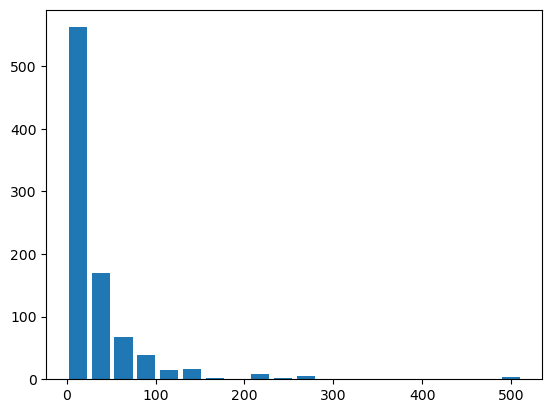

In [34]:
plt.hist(df.fare, bins = 20, rwidth = 0.8)

In [37]:
d2 = df[(df['fare'] < low) | (df['fare'] > high)]

(array([53., 18.,  7., 16.,  2.,  0.,  5.,  4.,  8.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  3.]),
 array([ 66.6    ,  88.88646, 111.17292, 133.45938, 155.74584, 178.0323 ,
        200.31876, 222.60522, 244.89168, 267.17814, 289.4646 , 311.75106,
        334.03752, 356.32398, 378.61044, 400.8969 , 423.18336, 445.46982,
        467.75628, 490.04274, 512.3292 ]),
 <BarContainer object of 20 artists>)

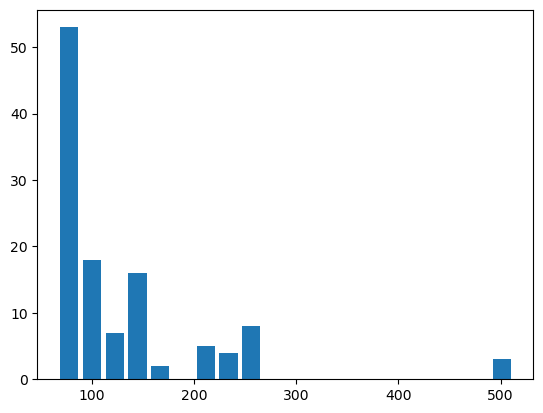

In [38]:
plt.hist(d2.fare, bins = 20, rwidth = 0.8)

In [39]:
d2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 116 entries, 1 to 879
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     116 non-null    int64   
 1   pclass       116 non-null    int64   
 2   sex          116 non-null    object  
 3   age          116 non-null    float64 
 4   sibsp        116 non-null    int64   
 5   parch        116 non-null    int64   
 6   fare         116 non-null    float64 
 7   embarked     116 non-null    object  
 8   class        116 non-null    category
 9   who          116 non-null    object  
 10  adult_male   116 non-null    bool    
 11  embark_town  114 non-null    object  
 12  alive        116 non-null    object  
 13  alone        116 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), object(5)
memory usage: 11.3+ KB


In [40]:
d2

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
1,1,1,female,38.000000,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
27,0,1,male,19.000000,3,2,263.0000,S,First,man,True,Southampton,no,False
31,1,1,female,29.699118,1,0,146.5208,C,First,woman,False,Cherbourg,yes,False
34,0,1,male,28.000000,1,0,82.1708,C,First,man,True,Cherbourg,no,False
52,1,1,female,49.000000,1,0,76.7292,C,First,woman,False,Cherbourg,yes,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
846,0,3,male,29.699118,8,2,69.5500,S,Third,man,True,Southampton,no,False
849,1,1,female,29.699118,1,0,89.1042,C,First,woman,False,Cherbourg,yes,False
856,1,1,female,45.000000,1,1,164.8667,S,First,woman,False,Southampton,yes,False
863,0,3,female,29.699118,8,2,69.5500,S,Third,woman,False,Southampton,no,False


In [42]:
from sklearn import LabelEn


ImportError: cannot import name 'LabelEncounder' from 'sklearn' (/home/nihal_farooq_m/miniconda3/envs/ml_env/lib/python3.9/site-packages/sklearn/__init__.py)